<a href="https://colab.research.google.com/github/ecourassis/vitaldb-oscilometria/blob/main/01_eda_vitaldb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA — concordância entre NIBP e ART no VitalDB

**Objetivo:** explorar a concordância entre a pressão arterial não invasiva oscilométrica (`NIBP`) e a pressão arterial invasiva (`ART`) no contexto intraoperatório.

O notebook baixa uma amostra determinística do VitalDB, pareia as medidas no tempo, avalia cobertura/diversidade, produz Bland–Altman e testa um modelo exploratório do erro. Ele não substitui validação formal segundo ISO 81060-2.


In [1]:
# Instalação automática das dependências no Google Colab.
%pip install -q matplotlib==3.9.2 numpy==2.1.1 pandas==2.2.3 requests==2.32.3 scikit-learn==1.5.2 scipy==1.14.1 seaborn==0.13.2 vitaldb==1.5.6

from pathlib import Path
from datetime import datetime, timezone
import platform, sys, warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, confusion_matrix
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import vitaldb

SEED = 42
N_CASES = 8          # aumente com cautela; o download ficará mais demorado
INTERVAL = 1         # segundos
PAIR_WINDOW = 30     # tolerância máxima para a referência temporal
np.random.seed(SEED)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
(ROOT / "data" / "cache").mkdir(parents=True, exist_ok=True)

print("Execução (UTC):", datetime.now(timezone.utc).isoformat())
print("Python:", sys.version.split()[0], "| Plataforma:", platform.platform())
print("pandas:", pd.__version__, "| numpy:", np.__version__, "| sklearn:", sklearn.__version__)
print({"seed": SEED, "n_cases": N_CASES, "interval_s": INTERVAL, "pair_window_s": PAIR_WINDOW})


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 5.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.3 which is incompatible.
google-adk 2.7.1 

## 1. Metadados e seleção dos casos

Selecionamos apenas casos que possuem simultaneamente NIBP, ART e frequência cardíaca. A amostra é determinística para que execuções sucessivas usem os mesmos casos.


In [2]:
CASES_URL = "https://api.vitaldb.net/cases"
TRACKS_URL = "https://api.vitaldb.net/trks"

cases = pd.read_csv(CASES_URL)
tracks = pd.read_csv(TRACKS_URL)
display(cases.head())
print("Casos clínicos:", len(cases), "| Registros de trilhas:", len(tracks))
print("Colunas de cases:", list(cases.columns))
print("Colunas de tracks:", list(tracks.columns))


,caseid,subjectid,casestart,caseend,anestart,aneend,opstart,opend,adm,dis,...,intraop_colloid,intraop_ppf,intraop_mdz,intraop_ftn,intraop_rocu,intraop_vecu,intraop_eph,intraop_phe,intraop_epi,intraop_ca
0,1,5955,0,11542,-552,10848.0,1668,10368,-236220,627780,...,0,120,0.0,100,70,0,10,0,0,0
1,2,2487,0,15741,-1039,14921.0,1721,14621,-221160,1506840,...,0,150,0.0,0,100,0,20,0,0,0
2,3,2861,0,4394,-590,4210.0,1090,3010,-218640,40560,...,0,0,0.0,0,50,0,0,0,0,0
3,4,1903,0,20990,-778,20222.0,2522,17822,-201120,576480,...,0,80,0.0,100,100,0,50,0,0,0
4,5,4416,0,21531,-1009,22391.0,2591,20291,-67560,3734040,...,0,0,0.0,0,160,0,10,900,0,2100


Casos clínicos: 6388 | Registros de trilhas: 486449
Colunas de cases: ['caseid', 'subjectid', 'casestart', 'caseend', 'anestart', 'aneend', 'opstart', 'opend', 'adm', 'dis', 'icu_days', 'death_inhosp', 'age', 'sex', 'height', 'weight', 'bmi', 'asa', 'emop', 'department', 'optype', 'dx', 'opname', 'approach', 'position', 'ane_type', 'preop_htn', 'preop_dm', 'preop_ecg', 'preop_pft', 'preop_hb', 'preop_plt', 'preop_pt', 'preop_aptt', 'preop_na', 'preop_k', 'preop_gluc', 'preop_alb', 'preop_ast', 'preop_alt', 'preop_bun', 'preop_cr', 'preop_ph', 'preop_hco3', 'preop_be', 'preop_pao2', 'preop_paco2', 'preop_sao2', 'cormack', 'airway', 'tubesize', 'dltubesize', 'lmasize', 'iv1', 'iv2', 'aline1', 'aline2', 'cline1', 'cline2', 'intraop_ebl', 'intraop_uo', 'intraop_rbc', 'intraop_ffp', 'intraop_crystalloid', 'intraop_colloid', 'intraop_ppf', 'intraop_mdz', 'intraop_ftn', 'intraop_rocu', 'intraop_vecu', 'intraop_eph', 'intraop_phe', 'intraop_epi', 'intraop_ca']
Colunas de tracks: ['caseid', 'tn

In [3]:
TRACKS = [
    "Solar8000/NIBP_SBP", "Solar8000/NIBP_MBP", "Solar8000/NIBP_DBP",
    "Solar8000/ART_SBP", "Solar8000/ART_MBP", "Solar8000/ART_DBP",
    "Solar8000/HR",
]

name_col = "tname" if "tname" in tracks.columns else "track_names"
eligible = (tracks[tracks[name_col].isin(TRACKS)]
            .groupby("caseid")[name_col].nunique())
eligible_ids = eligible[eligible >= 7].index.to_numpy()
selected_ids = np.sort(np.random.default_rng(SEED).choice(
    eligible_ids, size=min(N_CASES, len(eligible_ids)), replace=False
))
print("Casos elegíveis:", len(eligible_ids))
print("Amostra:", selected_ids.tolist())


Casos elegíveis: 3095
Amostra: [547, 567, 2738, 2769, 4191, 4480, 4974, 5502]


## 2. Download seletivo e construção da tabela analítica

`load_case` retorna as trilhas em uma grade regular de 1 segundo. Mantemos instantes com NIBP disponível e buscamos a mediana de ART em uma janela de ±30 s. A janela reduz o efeito de ruído pontual, mas pode introduzir erro em mudanças hemodinâmicas rápidas — uma limitação que deve acompanhar os resultados.


In [4]:
def load_one_case(caseid):
    arr = vitaldb.load_case(int(caseid), TRACKS, interval=INTERVAL)
    df = pd.DataFrame(arr, columns=[x.split("/")[-1] for x in TRACKS])
    df["time_s"] = np.arange(len(df)) * INTERVAL
    df["caseid"] = int(caseid)

    # ART suavizada localmente serve como referência temporal da aferição NIBP.
    win = max(3, int(2 * PAIR_WINDOW / INTERVAL) + 1)
    for suffix in ["SBP", "MBP", "DBP"]:
        df[f"ART_{suffix}_ref"] = df[f"ART_{suffix}"].rolling(
            win, center=True, min_periods=1
        ).median()

    # Uma linha por atualização NIBP; remove repetições consecutivas do mesmo triplo.
    nibp_cols = ["NIBP_SBP", "NIBP_MBP", "NIBP_DBP"]
    has_nibp = df[nibp_cols].notna().all(axis=1)
    changed = df[nibp_cols].ne(df[nibp_cols].shift()).any(axis=1)
    return df.loc[has_nibp & changed].copy()

parts, failures = [], []
for cid in selected_ids:
    try:
        part = load_one_case(cid)
        if not part.empty:
            parts.append(part)
        print(f"caseid={cid}: {len(part)} medidas NIBP")
    except Exception as exc:
        failures.append((int(cid), str(exc)))
        warnings.warn(f"Falha no caso {cid}: {exc}")

if not parts:
    raise RuntimeError("Nenhum caso foi carregado. Verifique a conexão e a disponibilidade da API.")

paired = pd.concat(parts, ignore_index=True)
paired = paired.merge(cases, on="caseid", how="left", suffixes=("", "_clinical"))
print("Falhas:", failures)
print("Linhas antes dos filtros:", len(paired))


caseid=547: 610 medidas NIBP
caseid=567: 2062 medidas NIBP
caseid=2738: 4038 medidas NIBP
caseid=2769: 2065 medidas NIBP
caseid=4191: 2519 medidas NIBP
caseid=4480: 1525 medidas NIBP
caseid=4974: 2319 medidas NIBP
caseid=5502: 483 medidas NIBP
Falhas: []
Linhas antes dos filtros: 15621


In [5]:
# Regras exploratórias de plausibilidade; não são limites regulatórios.
ranges = {
    "NIBP_SBP": (40, 260), "NIBP_MBP": (25, 200), "NIBP_DBP": (20, 160),
    "ART_SBP_ref": (40, 260), "ART_MBP_ref": (25, 200), "ART_DBP_ref": (20, 160),
    "HR": (20, 220),
}
mask = pd.Series(True, index=paired.index)
for col, (lo, hi) in ranges.items():
    mask &= paired[col].between(lo, hi)

excluded = int((~mask).sum())
paired = paired.loc[mask].copy()
paired["bmi"] = paired["weight"] / (paired["height"] / 100) ** 2
paired["time_min"] = paired["time_s"] / 60
for suffix in ["SBP", "MBP", "DBP"]:
    paired[f"error_{suffix}"] = paired[f"NIBP_{suffix}"] - paired[f"ART_{suffix}_ref"]
paired["art_hypotension"] = paired["ART_MBP_ref"] < 65
paired["nibp_hypotension"] = paired["NIBP_MBP"] < 65

print("Excluídas por ausência/implausibilidade:", excluded)
print("Pares analíticos:", len(paired), "| Casos:", paired.caseid.nunique())
display(paired.head())


Excluídas por ausência/implausibilidade: 3595
Pares analíticos: 12026 | Casos: 7


,NIBP_SBP,NIBP_MBP,NIBP_DBP,ART_SBP,ART_MBP,ART_DBP,HR,time_s,caseid,ART_SBP_ref,...,intraop_eph,intraop_phe,intraop_epi,intraop_ca,time_min,error_SBP,error_MBP,error_DBP,art_hypotension,nibp_hypotension
257,141.0,107.0,82.0,NaN,169.0,NaN,86.0,566,547,110.5,...,0,0,0,0,9.433333,30.5,-62.0,-17.0,False,False
270,141.0,107.0,82.0,NaN,256.0,NaN,82.0,592,547,176.0,...,0,0,0,0,9.866667,-35.0,-63.0,-56.0,False,False
271,141.0,107.0,82.0,NaN,231.0,NaN,82.0,594,547,134.0,...,0,0,0,0,9.900000,7.0,-63.0,3.0,False,False
272,141.0,107.0,82.0,NaN,200.0,NaN,82.0,596,547,134.5,...,0,0,0,0,9.933333,6.5,-63.0,3.0,False,False
273,141.0,107.0,82.0,NaN,161.0,NaN,83.0,598,547,134.5,...,0,0,0,0,9.966667,6.5,-63.0,3.0,False,False


## 3. Cobertura, diversidade e distribuições

In [6]:
coverage = pd.DataFrame({
    "tipo": paired.dtypes.astype(str),
    "ausentes_n": paired.isna().sum(),
    "ausentes_pct": (100 * paired.isna().mean()).round(1),
    "unicos": paired.nunique(dropna=True),
}).sort_values("ausentes_pct", ascending=False)
display(coverage.head(20))

demo_cols = [c for c in ["sex", "age", "height", "weight", "bmi"] if c in paired]
display(paired.groupby("caseid")[demo_cols].first().describe(include="all").T)


,tipo,ausentes_n,ausentes_pct,unicos
dltubesize,object,12026,100.0,0
cline2,object,12026,100.0,0
lmasize,float64,12026,100.0,0
iv2,object,10383,86.3,1
preop_hco3,float64,9994,83.1,2
preop_sao2,float64,9994,83.1,2
preop_paco2,float64,9994,83.1,2
preop_ph,float64,9994,83.1,2
preop_pao2,float64,9994,83.1,2
preop_be,float64,9994,83.1,2


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
sex,7,2,M,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,7.0,NaN,NaN,NaN,57.571429,9.162553,48.0,51.0,55.0,62.0,74.0
height,7.0,NaN,NaN,NaN,160.857143,6.147861,153.7,155.6,161.8,164.65,170.0
weight,7.0,NaN,NaN,NaN,61.964286,11.537862,43.8,56.45,60.9,68.325,79.5
bmi,7.0,NaN,NaN,NaN,24.060735,4.63775,15.155709,22.602903,25.056769,27.164766,28.677326


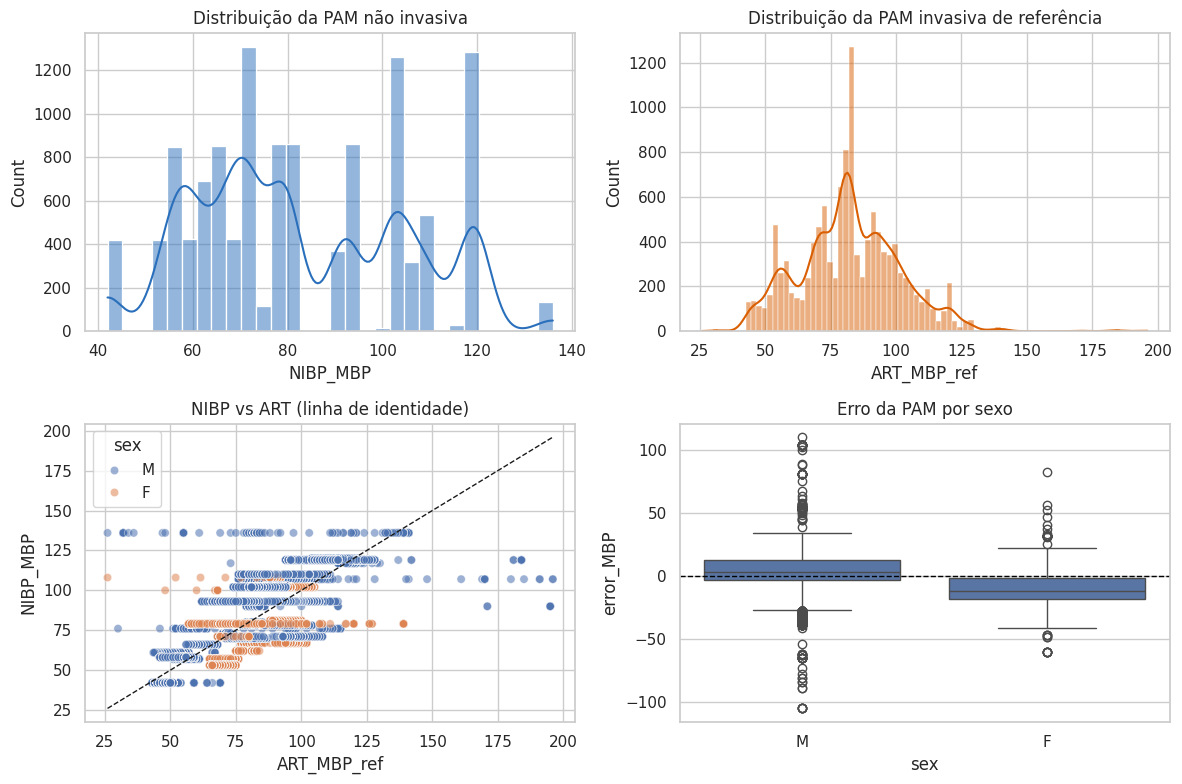

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(paired, x="NIBP_MBP", kde=True, ax=axes[0, 0], color="#2a6fbb")
axes[0, 0].set_title("Distribuição da PAM não invasiva")
sns.histplot(paired, x="ART_MBP_ref", kde=True, ax=axes[0, 1], color="#d95f02")
axes[0, 1].set_title("Distribuição da PAM invasiva de referência")
sns.scatterplot(paired, x="ART_MBP_ref", y="NIBP_MBP", hue="sex", alpha=.55, ax=axes[1, 0])
lims = [min(paired.ART_MBP_ref.min(), paired.NIBP_MBP.min()), max(paired.ART_MBP_ref.max(), paired.NIBP_MBP.max())]
axes[1, 0].plot(lims, lims, "k--", linewidth=1)
axes[1, 0].set_title("NIBP vs ART (linha de identidade)")
sns.boxplot(paired, x="sex", y="error_MBP", ax=axes[1, 1])
axes[1, 1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1, 1].set_title("Erro da PAM por sexo")
plt.tight_layout()
plt.show()


## 4. Concordância e erro

In [8]:
rows = []
for suffix in ["SBP", "MBP", "DBP"]:
    y = paired[f"ART_{suffix}_ref"]
    p = paired[f"NIBP_{suffix}"]
    d = p - y
    rows.append({
        "pressao": suffix,
        "n": len(d),
        "vies_medio_mmHg": d.mean(),
        "dp_diferenca_mmHg": d.std(ddof=1),
        "mae_mmHg": mean_absolute_error(y, p),
        "rmse_mmHg": mean_squared_error(y, p) ** 0.5,
        "correlacao_pearson": y.corr(p),
    })
metrics = pd.DataFrame(rows).round(2)
display(metrics)
print("Correlação é apresentada apenas como complemento; não substitui análise de concordância.")


,pressao,n,vies_medio_mmHg,dp_diferenca_mmHg,mae_mmHg,rmse_mmHg,correlacao_pearson
0,SBP,12026,-3.44,21.79,17.73,22.06,0.59
1,MBP,12026,0.07,16.33,12.39,16.32,0.70
2,DBP,12026,3.49,13.19,10.99,13.64,0.69


Correlação é apresentada apenas como complemento; não substitui análise de concordância.


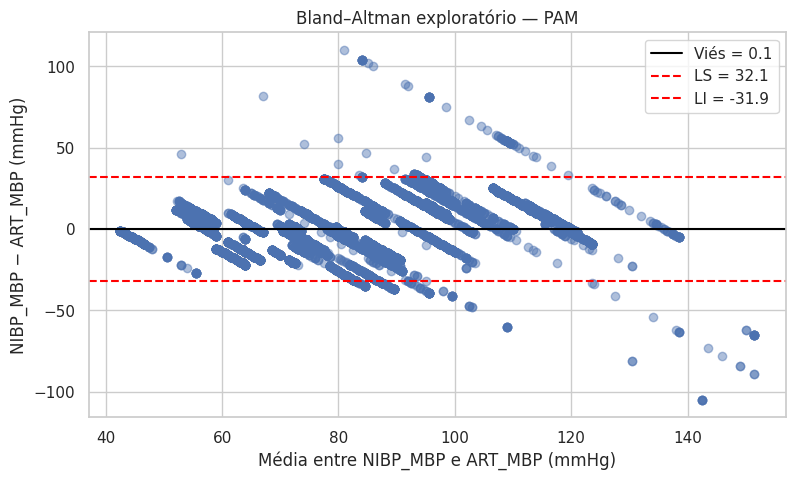

In [9]:
mean_bp = (paired["NIBP_MBP"] + paired["ART_MBP_ref"]) / 2
diff = paired["error_MBP"]
bias = diff.mean()
sd = diff.std(ddof=1)

plt.figure(figsize=(9, 5))
plt.scatter(mean_bp, diff, alpha=.45)
plt.axhline(bias, color="black", label=f"Viés = {bias:.1f}")
plt.axhline(bias + 1.96*sd, color="red", linestyle="--", label=f"LS = {bias+1.96*sd:.1f}")
plt.axhline(bias - 1.96*sd, color="red", linestyle="--", label=f"LI = {bias-1.96*sd:.1f}")
plt.xlabel("Média entre NIBP_MBP e ART_MBP (mmHg)")
plt.ylabel("NIBP_MBP − ART_MBP (mmHg)")
plt.title("Bland–Altman exploratório — PAM")
plt.legend()
plt.show()


## 5. Classificação exploratória de hipotensão

In [10]:
cm = confusion_matrix(paired["art_hypotension"], paired["nibp_hypotension"], labels=[False, True])
tn, fp, fn, tp = cm.ravel()
safe = lambda a, b: a / b if b else np.nan
classification = pd.Series({
    "sensibilidade": safe(tp, tp+fn),
    "especificidade": safe(tn, tn+fp),
    "VPP": safe(tp, tp+fp),
    "VPN": safe(tn, tn+fn),
    "prevalencia_ART": paired["art_hypotension"].mean(),
}).round(3)
display(pd.DataFrame(cm, index=["ART não", "ART sim"], columns=["NIBP não", "NIBP sim"]))
display(classification.to_frame("valor"))


,NIBP não,NIBP sim
ART não,8699,1263
ART sim,525,1539


,valor
sensibilidade,0.746
especificidade,0.873
VPP,0.549
VPN,0.943
prevalencia_ART,0.172


## 6. ML exploratório: fatores associados ao erro

O alvo é `NIBP_MBP − ART_MBP`. O particionamento é feito por `caseid`, evitando que medidas do mesmo paciente apareçam simultaneamente em treino e teste. Com apenas oito casos, o resultado serve para demonstrar o pipeline, não para conclusão clínica.


In [11]:
candidate_features = ["NIBP_MBP", "HR", "age", "weight", "height", "bmi", "time_min", "sex"]
features = [c for c in candidate_features if c in paired.columns]
model_df = paired[features + ["error_MBP", "caseid"]].copy()

numeric = [c for c in features if c != "sex"]
categorical = [c for c in features if c == "sex"]
pre = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical),
])
model = Pipeline([
    ("pre", pre),
    ("rf", RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                                  random_state=SEED, n_jobs=-1)),
])

splitter = GroupShuffleSplit(n_splits=1, test_size=.25, random_state=SEED)
train_idx, test_idx = next(splitter.split(model_df, groups=model_df["caseid"]))
train, test = model_df.iloc[train_idx], model_df.iloc[test_idx]
model.fit(train[features], train["error_MBP"])
pred = model.predict(test[features])
baseline = np.repeat(train["error_MBP"].mean(), len(test))

result = pd.DataFrame({
    "modelo": ["baseline_média", "random_forest"],
    "MAE": [mean_absolute_error(test.error_MBP, baseline), mean_absolute_error(test.error_MBP, pred)],
    "RMSE": [mean_squared_error(test.error_MBP, baseline)**.5, mean_squared_error(test.error_MBP, pred)**.5],
}).round(2)
display(result)
print("Casos treino:", train.caseid.nunique(), "| Casos teste:", test.caseid.nunique())


,modelo,MAE,RMSE
0,baseline_média,14.56,17.40
1,random_forest,8.28,11.64


Casos treino: 5 | Casos teste: 2


## 7. Conclusões e checklist de interpretação

Após executar, descreva: (1) cobertura e número de casos/pares; (2) viés, dispersão, MAE e limites de concordância; (3) desempenho na identificação de PAM < 65 mmHg; (4) heterogeneidade por sexo, idade, IMC e tempo; (5) desempenho do modelo apenas como exploração.

Não conclua que o equipamento é “aprovado” ou “reprovado”. Os dados são observacionais, NIBP e ART têm fontes de erro diferentes e faltam elementos do protocolo normativo. Uma ampliação adequada deve incluir mais casos, análise de sensibilidade da janela temporal, intervalos de confiança por bootstrap agrupado por paciente e validação externa.
